In [1]:
import pandas as pd

df = pd.read_csv("moex_close_2015_2025_no_apimoex.csv")
df.head()

,date,close,SECID
0,2015-01-05,33.21,AFLT
1,2015-01-06,33.07,AFLT
2,2015-01-08,35.17,AFLT
3,2015-01-09,34.00,AFLT
4,2015-01-12,34.45,AFLT


In [ ]:
import numpy as np
# NaN
missing_nan = (
    df
    .groupby("SECID")["close"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

# нули
missing_zero = (
    df
    .groupby("SECID")["close"]
    .apply(lambda x: (x == 0).sum())
    .sort_values(ascending=False)
)

# NaN + нули вместе
missing_bad = (
    df
    .groupby("SECID")["close"]
    .apply(lambda x: x.isna().sum() + (x == 0).sum())
    .sort_values(ascending=False)
)


NaN по тикерам:
 SECID
KUZB    141
BRZL    136
UKUZ    119
FEES     32
UTAR     28
VTBR     22
PLZL     21
MTLR     20
TRMK     20
RASP     20
NMTP     20
MVID     20
IRKT     20
GCHE     20
APTK     20
BANE     20
CHMF     18
TATN     18
SNGS     18
SBER     18
Name: close, dtype: int64
Нули по тикерам:
 SECID
AFLT    0
NLMK    0
UTAR    0
UKUZ    0
TRMK    0
TATN    0
SNGS    0
SBER    0
RASP    0
PLZL    0
PIKK    0
PHOR    0
NVTK    0
NMTP    0
MVID    0
ALRS    0
MTSS    0
MTLR    0
MOEX    0
MGNT    0
Name: close, dtype: int64
NaN+нули по тикерам:
 SECID
KUZB    141
BRZL    136
UKUZ    119
FEES     32
UTAR     28
VTBR     22
PLZL     21
MTLR     20
TRMK     20
RASP     20
NMTP     20
MVID     20
IRKT     20
GCHE     20
APTK     20
BANE     20
CHMF     18
TATN     18
SNGS     18
SBER     18
Name: close, dtype: int64


In [12]:
print("NaN по тикерам:\n", missing_nan.head(30))

NaN по тикерам:
 SECID
KUZB    141
BRZL    136
UKUZ    119
FEES     32
UTAR     28
VTBR     22
PLZL     21
MTLR     20
TRMK     20
RASP     20
NMTP     20
MVID     20
IRKT     20
GCHE     20
APTK     20
BANE     20
CHMF     18
TATN     18
SNGS     18
SBER     18
MOEX     18
MTSS     18
PIKK     18
PHOR     18
NVTK     18
MGNT     18
NLMK     18
ALRS     18
AFLT     18
Name: close, dtype: int64


In [13]:
print("Нули по тикерам:\n", missing_zero.tail(10))

Нули по тикерам:
 SECID
MGNT    0
KUZB    0
IRKT    0
GCHE    0
FEES    0
CHMF    0
BRZL    0
BANE    0
APTK    0
VTBR    0
Name: close, dtype: int64


In [14]:
print("NaN+нули по тикерам:\n", missing_bad.tail(10))

NaN+нули по тикерам:
 SECID
SBER    18
MOEX    18
MTSS    18
PIKK    18
PHOR    18
NVTK    18
MGNT    18
NLMK    18
ALRS    18
AFLT    18
Name: close, dtype: int64


итого разброс пропусков от 18 до 141, всего 2781 записей - норм

In [3]:
all_dates = df['date'].drop_duplicates().sort_values()

missing_dates = (
    df.groupby('SECID')['date']
    .apply(lambda x: len(all_dates) - x.nunique())
    .sort_values(ascending=False)
)

missing_dates.head(20)

SECID
AFLT    0
NLMK    0
UTAR    0
UKUZ    0
TRMK    0
TATN    0
SNGS    0
SBER    0
RASP    0
PLZL    0
PIKK    0
PHOR    0
NVTK    0
NMTP    0
MVID    0
ALRS    0
MTSS    0
MTLR    0
MOEX    0
MGNT    0
Name: date, dtype: int64

можно убрать - у новых данных меньше пропусков

In [4]:
df['date'] = pd.to_datetime(df['date'])
pivot = (
    df
    .pivot(index='date', columns='SECID', values='close')
    .sort_index()
)

missing_ratio = pivot.isna().sum() / pivot.shape[0]

# Фильтрация
threshold = 0.4
valid_tickers = missing_ratio[missing_ratio <= threshold].index

pivot_clean = pivot[valid_tickers]

In [5]:
pivot_clean.head()

SECID,AFLT,ALRS,APTK,BANE,BRZL,CHMF,FEES,GCHE,IRKT,KUZB,...,PIKK,PLZL,RASP,SBER,SNGS,TATN,TRMK,UKUZ,UTAR,VTBR
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,33.21,60.38,12.94,1245.0,499.0,522.00,0.04713,702.0,5.45,NaN,...,191.7,1000.5,23.15,56.37,24.240,238.00,37.5,598.0,8.40,0.06750
2015-01-06,33.07,61.28,13.46,1241.0,NaN,556.90,0.04850,703.0,5.50,NaN,...,198.9,1047.0,23.43,58.28,25.015,228.75,37.9,640.0,9.25,0.06666
2015-01-08,35.17,60.20,13.90,1281.0,500.0,542.70,0.05030,686.0,5.67,NaN,...,191.2,1060.0,24.25,65.70,26.265,245.00,38.0,573.0,9.60,0.06741
2015-01-09,34.00,61.91,13.69,1291.0,500.0,548.55,0.04897,680.0,5.77,NaN,...,192.7,1050.0,23.80,63.10,25.650,234.05,39.2,589.0,9.25,0.06531
2015-01-12,34.45,63.00,13.57,1270.0,431.0,558.45,0.04955,691.0,5.73,NaN,...,188.0,1020.0,23.22,62.90,25.450,228.25,38.4,588.0,9.40,0.06353


In [7]:
# Задание 2а
# Доходности
import numpy as np

returns = pivot_clean.pct_change().iloc[1:]

# очистка выбросов
returns = returns.copy()
returns[returns > 1] = np.nan
returns[returns < -1] = np.nan

# Окна (в торговых днях)
windows = {
    "1Y": 252,
    "1Q": 63,
    "1M": 21,
    "1W": 5,
    "1D": 1
}

# Даты
target_dates = pd.to_datetime([
    "2025-12-01",
    "2022-02-16",
    "2018-06-14"
])

# Ближайшая торговая дата
def get_nearest_date(target_date, index):
    return index[index.get_indexer([target_date], method='nearest')[0]]

# Расчёт
results = {}

for date in target_dates:
    nearest_date = get_nearest_date(date, returns.index)
    results[nearest_date] = {}

    end_loc = returns.index.get_loc(nearest_date)

    for name, window in windows.items():

        if end_loc < window:
            mean_returns = None
            cov_matrix = None

        else:
            window_data = returns.iloc[end_loc - window:end_loc]

            # вектор доходностей
            mean_returns = window_data.mean()

            # ковариационная матрица
            cov_matrix = window_data.cov()

        results[nearest_date][name] = {
            "mean": mean_returns,
            "cov": cov_matrix
        }

# Вывод
for date, data in results.items():
    print(f"\n Дата: {date} ")

    for w, res in data.items():
        print(f"\n Окно: {w} ")

        if res["mean"] is not None:
            print("\n Вектор доходностей:")
            print(res["mean"].round(6))

            print("\n Ковариационная матрица:")
            print(res["cov"].round(6))
        else:
            print("Недостаточно данных")


 Дата: 2025-12-01 00:00:00 

 Окно: 1Y 

 Вектор доходностей:
SECID
AFLT    0.000980
ALRS   -0.000495
APTK   -0.000590
BANE   -0.001071
BRZL   -0.000573
CHMF   -0.000339
FEES   -0.000026
GCHE   -0.000440
IRKT    0.000579
KUZB    0.000536
MGNT   -0.001543
MOEX   -0.000113
MTLR    0.000019
MTSS    0.001050
MVID   -0.000197
NLMK   -0.000273
NMTP    0.000484
NVTK    0.001731
PHOR    0.000650
PIKK    0.001224
PLZL   -0.001772
RASP   -0.001199
SBER    0.001237
SNGS   -0.000230
TATN    0.000700
TRMK    0.000641
UKUZ   -0.000431
UTAR   -0.000965
VTBR    0.000727
dtype: float64

 Ковариационная матрица:
SECID      AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
SECID                                                                         
AFLT   0.000648  0.000371  0.000156  0.000272  0.000095  0.000427  0.000330   
ALRS   0.000371  0.000431  0.000143  0.000259  0.000109  0.000376  0.000271   
APTK   0.000156  0.000143  0.000299  0.000177  0.000086  0.000183  0.000119   
BA

/var/folders/t7/_1s6288s0z3_42t_mg_vn43w0000gn/T/ipykernel_89593/2008161944.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot_clean.pct_change().iloc[1:]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/frame.py:11218: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [15]:
import numpy as np

analysis_results = []

for date, data in results.items():
    for window, res in data.items():

        cov = res["cov"]
        mean = res["mean"]

        if cov is None:
            continue

        # Средняя дисперсия (средний риск акций)
        avg_var = np.mean(np.diag(cov))

        # Общий риск системы
        total_risk = np.trace(cov)

        # Максимальный риск (самая волатильная акция)
        max_var = np.max(np.diag(cov))

        # Средняя корреляция
        std = np.sqrt(np.diag(cov))
        corr = cov / np.outer(std, std)
        avg_corr = corr.values[np.triu_indices_from(corr, k=1)].mean()

        # Средняя доходность
        avg_return = mean.mean()

        analysis_results.append({
            "date": date,
            "window": window,
            "avg_var": avg_var,
            "total_risk": total_risk,
            "max_var": max_var,
            "avg_corr": avg_corr,
            "avg_return": avg_return
        })

analysis_df = pd.DataFrame(analysis_results)

# Вывод
analysis_df.sort_values(["date", "window"])

,date,window,avg_var,total_risk,max_var,avg_corr,avg_return
14,2018-06-14,1D,NaN,NaN,NaN,NaN,0.000515
12,2018-06-14,1M,0.000238,0.006888,0.000998,0.059732,-0.000210
11,2018-06-14,1Q,0.000389,0.011288,0.001205,0.282763,-0.000564
13,2018-06-14,1W,0.000297,0.008625,0.003105,0.198478,-0.001395
10,2018-06-14,1Y,0.000334,0.009700,0.000663,0.147098,0.000435
9,2022-02-16,1D,NaN,NaN,NaN,NaN,0.027292
7,2022-02-16,1M,0.000950,0.027536,0.003198,0.521370,0.000910
6,2022-02-16,1Q,0.000783,0.022696,0.002613,0.408986,-0.001174
8,2022-02-16,1W,0.001029,0.029838,0.004293,0.571529,0.006129
5,2022-02-16,1Y,0.000664,0.019242,0.004099,0.212875,0.000720


In [16]:
#Выводы

#1. Зависимость оценок от длины окна
#Оценки риска и взаимосвязи активов существенно зависят от длины используемого окна:
#при сокращении окна наблюдается рост волатильности и корреляций, что свидетельствует о высокой чувствительности краткосрочных оценок к рыночному шуму.

#2. Нестабильность краткосрочных оценок
#Короткие окна (1 неделя, 1 месяц) дают более волатильные и нестабильные оценки ковариации,
#что делает их менее надёжными для построения портфеля по сравнению с более длинными окнами.

#3. Кризисный эффект (2022)
#В кризисный период (2022 год) наблюдается резкий рост как волатильности, так и корреляции между активами,
#что указывает на синхронизацию их движения и существенное снижение возможностей диверсификации.

#4. Ограниченность диверсификации
#Во всех рассмотренных периодах ковариации между активами в основном положительны, что указывает на ограниченные возможности снижения риска за счёт диверсификации,
#особенно в стрессовые периоды.

#5. Различие между периодами
#В спокойные периоды (например, 2018 год) наблюдаются более низкие и менее стабильные корреляции,
#что создаёт лучшие условия для диверсификации по сравнению с более поздними периодами.

In [17]:
# Задание 2б
# Доходности
returns = pivot_clean.pct_change().iloc[1:]

# очистка выбросов
returns = returns.copy()
returns[returns > 1] = np.nan
returns[returns < -1] = np.nan

# Шаги (в торговых днях)
steps = {
    "1Y": 252,
    "1Q": 63,
    "1M": 21,
    "1W": 5,
    "1D": 1
}

# Даты
target_dates = pd.to_datetime([
    "2025-12-01",
    "2022-02-16",
    "2018-06-14"
])

# Ближайшая торговая дата
def get_nearest_date(target_date, index):
    return index[index.get_indexer([target_date], method='nearest')[0]]

# расчёт
expanding_results = {}

for date in target_dates:
    nearest_date = get_nearest_date(date, returns.index)
    expanding_results[nearest_date] = {}

    end_loc = returns.index.get_loc(nearest_date)

    for name, step in steps.items():

        if end_loc < step:
            mean_returns = None
            cov_matrix = None

        else:
            # expanding: от начала до текущей точки
            window_data = returns.iloc[:end_loc]

            # (шаг здесь влияет только на условие минимального размера окна)

            mean_returns = window_data.mean()
            cov_matrix = window_data.cov()

        expanding_results[nearest_date][name] = {
            "mean": mean_returns,
            "cov": cov_matrix
        }

# Вывод
for date, data in expanding_results.items():
    print(f"\n Дата: {date} ")

    for w, res in data.items():
        print(f"\n Окно (expanding): {w} ")

        if res["mean"] is not None:
            print("\nВектор доходностей:")
            print(res["mean"].round(6))

            print("\nКовариационная матрица:")
            print(res["cov"].round(6))
        else:
            print("Недостаточно данных")


 Дата: 2025-12-01 00:00:00 

 Окно (expanding): 1Y 

Вектор доходностей:
SECID
AFLT    0.000466
ALRS    0.000055
APTK    0.000146
BANE    0.000286
BRZL    0.000785
CHMF    0.000411
FEES    0.000374
GCHE    0.000755
IRKT    0.001169
KUZB    0.001075
MGNT   -0.000221
MOEX    0.000542
MTLR    0.000975
MTSS    0.000236
MVID    0.000034
NLMK    0.000377
NMTP    0.000987
NVTK    0.000563
PHOR    0.000610
PIKK    0.000562
PLZL    0.001019
RASP    0.001112
SBER    0.000841
SNGS    0.000190
TATN    0.000592
TRMK    0.000714
UKUZ    0.000795
UTAR    0.000492
VTBR   -0.000276
dtype: float64

Ковариационная матрица:
SECID      AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
SECID                                                                         
AFLT   0.000531  0.000181  0.000109  0.000160  0.000094  0.000171  0.000204   
ALRS   0.000181  0.000411  0.000084  0.000128  0.000085  0.000170  0.000187   
APTK   0.000109  0.000084  0.000664  0.000084  0.000070  0.000086  0.00

/var/folders/t7/_1s6288s0z3_42t_mg_vn43w0000gn/T/ipykernel_89593/1086584097.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot_clean.pct_change().iloc[1:]


In [18]:
analysis_expanding = []

for date, data in expanding_results.items():
    for window, res in data.items():

        cov = res["cov"]
        mean = res["mean"]

        if cov is None:
            continue

        # Средняя дисперсия
        avg_var = np.mean(np.diag(cov))

        # Общий риск
        total_risk = np.trace(cov)

        # Максимальная дисперсия
        max_var = np.max(np.diag(cov))

        # Средняя корреляция
        std = np.sqrt(np.diag(cov))
        corr = cov / np.outer(std, std)
        avg_corr = corr.values[np.triu_indices_from(corr, k=1)].mean()

        # Средняя доходность
        avg_return = mean.mean()

        analysis_expanding.append({
            "date": date,
            "window": window,
            "avg_var": avg_var,
            "total_risk": total_risk,
            "max_var": max_var,
            "avg_corr": avg_corr,
            "avg_return": avg_return
        })

analysis_expanding_df = pd.DataFrame(analysis_expanding)
analysis_expanding_df.sort_values(["date", "window"])

,date,window,avg_var,total_risk,max_var,avg_corr,avg_return
14,2018-06-14,1D,0.000608,0.017645,0.002804,0.115873,0.001017
12,2018-06-14,1M,0.000608,0.017645,0.002804,0.115873,0.001017
11,2018-06-14,1Q,0.000608,0.017645,0.002804,0.115873,0.001017
13,2018-06-14,1W,0.000608,0.017645,0.002804,0.115873,0.001017
10,2018-06-14,1Y,0.000608,0.017645,0.002804,0.115873,0.001017
9,2022-02-16,1D,0.000557,0.016145,0.002162,0.147241,0.000794
7,2022-02-16,1M,0.000557,0.016145,0.002162,0.147241,0.000794
6,2022-02-16,1Q,0.000557,0.016145,0.002162,0.147241,0.000794
8,2022-02-16,1W,0.000557,0.016145,0.002162,0.147241,0.000794
5,2022-02-16,1Y,0.000557,0.016145,0.002162,0.147241,0.000794


In [ ]:
# Выводы
# 1. Независимость от длины окна
# При использовании расширяющегося окна оценки риска и доходности не зависят от выбранного горизонта (1Y, 1M, 1W и т.д.),
# так как расчёты ведутся на всей накопленной истории наблюдений.

# 2. Стабильность оценок риска
# Оценки волатильности и совокупного риска практически не изменяются во времени, что свидетельствует о высокой устойчивости метода,
# но одновременно указывает на его низкую чувствительность к текущим изменениям рынка.

# 3. Сглаживание кризисных эффектов
# В отличие от скользящего окна, расширяющееся окно не фиксирует резкий рост риска в кризисный период (2022 год),
# так как влияние шоков размывается за счёт включения всей исторической выборки.

# 4. Рост корреляций во времени
# Наблюдается постепенное увеличение средней корреляции между активами,
# что может свидетельствовать о росте синхронности движения рынка и снижении эффективности диверсификации.

# 5. Ограниченная применимость для портфельного управления
# Несмотря на стабильность, расширяюшееся окно менее пригодно для практического управления портфелем,
# так как не отражает актуальные рыночные условия и может приводить к запаздывающим инвестиционным решениям.

# 6. Ключевое отличие от скользящего
# Расширяющееся окно обеспечивает устойчивые, но инертные оценки,
# тогда как скользящее окно позволяет лучше учитывать текущую рыночную динамику и кризисные изменения.

In [19]:
# Задание 3

# Очистка выбросов
returns = returns.copy()
returns[(returns > 1) | (returns < -1)] = np.nan

# Параметр забывания
lambda_ = 0.94

# Даты
target_dates = pd.to_datetime([
    "2025-12-01",
    "2022-02-16",
    "2018-06-14"
])

# Ближайшая дата
def get_nearest_date(target_date, index):
    return index[index.get_indexer([target_date], method='nearest')[0]]

# EWMA ковариация
def ewma_covariance(data, lambda_):
    n_assets = data.shape[1]
    cov = np.zeros((n_assets, n_assets))

    # начинаем с нулевой матрицы
    for i in range(len(data)):
        r = data.iloc[i].values.reshape(-1, 1)

        if np.isnan(r).any():
            continue

        cov = lambda_ * cov + (1 - lambda_) * (r @ r.T)

    return pd.DataFrame(cov, index=data.columns, columns=data.columns)

# Расчёт
ewma_results = {}

for date in target_dates:
    nearest_date = get_nearest_date(date, returns.index)

    window_data = returns.loc[:nearest_date]

    mean_returns = window_data.mean()
    cov_matrix = ewma_covariance(window_data, lambda_)

    ewma_results[nearest_date] = {
        "mean": mean_returns,
        "cov": cov_matrix
    }

for date, res in ewma_results.items():
    print(f"\n Дата: {date}")

    print("\nВектор доходностей:")
    print(res["mean"].round(6))

    print("\nКовариационная матрица (EWMA):")
    print(res["cov"].round(6))


 Дата: 2025-12-01 00:00:00

Вектор доходностей:
SECID
AFLT    0.000464
ALRS    0.000054
APTK    0.000148
BANE    0.000285
BRZL    0.000783
CHMF    0.000413
FEES    0.000372
GCHE    0.000755
IRKT    0.001173
KUZB    0.001075
MGNT   -0.000227
MOEX    0.000542
MTLR    0.000991
MTSS    0.000240
MVID    0.000033
NLMK    0.000385
NMTP    0.000984
NVTK    0.000568
PHOR    0.000610
PIKK    0.000564
PLZL    0.001020
RASP    0.001112
SBER    0.000842
SNGS    0.000190
TATN    0.000587
TRMK    0.000713
UKUZ    0.000795
UTAR    0.000488
VTBR   -0.000278
dtype: float64

Ковариационная матрица (EWMA):
SECID      AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
SECID                                                                         
AFLT   0.000605  0.000270  0.000190  0.000193  0.000085  0.000366  0.000215   
ALRS   0.000270  0.000204  0.000100  0.000114  0.000071  0.000231  0.000137   
APTK   0.000190  0.000100  0.000133  0.000087  0.000029  0.000129  0.000074   
BANE   0.0

In [20]:
comparison = []

for date in ewma_results.keys():

    # EWMA
    cov_ewma = ewma_results[date]["cov"]
    mean_ewma = ewma_results[date]["mean"]

    # Rolling
    cov_roll = results[date]["1Y"]["cov"]
    mean_roll = results[date]["1Y"]["mean"]

    if cov_roll is None or cov_ewma is None:
        continue

    # функции для метрик
    def compute_metrics(cov, mean):
        avg_var = np.mean(np.diag(cov))
        total_risk = np.trace(cov)
        max_var = np.max(np.diag(cov))

        std = np.sqrt(np.diag(cov))
        corr = cov / np.outer(std, std)
        avg_corr = corr.values[np.triu_indices_from(corr, k=1)].mean()

        avg_return = mean.mean()

        return avg_var, total_risk, max_var, avg_corr, avg_return

    # расчет
    roll_metrics = compute_metrics(cov_roll, mean_roll)
    ewma_metrics = compute_metrics(cov_ewma, mean_ewma)

    comparison.append({
        "date": date,

        "roll_avg_var": roll_metrics[0],
        "ewma_avg_var": ewma_metrics[0],

        "roll_total_risk": roll_metrics[1],
        "ewma_total_risk": ewma_metrics[1],

        "roll_max_var": roll_metrics[2],
        "ewma_max_var": ewma_metrics[2],

        "roll_avg_corr": roll_metrics[3],
        "ewma_avg_corr": ewma_metrics[3],

        "roll_avg_return": roll_metrics[4],
        "ewma_avg_return": ewma_metrics[4],

        # разница
        "risk_diff": ewma_metrics[1] - roll_metrics[1],
        "corr_diff": ewma_metrics[3] - roll_metrics[3]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,date,roll_avg_var,ewma_avg_var,roll_total_risk,ewma_total_risk,roll_max_var,ewma_max_var,roll_avg_corr,ewma_avg_corr,roll_avg_return,ewma_avg_return,risk_diff,corr_diff
0,2025-12-01,0.000656,0.000377,0.019010,0.010934,0.003624,0.001020,0.426037,0.504494,0.000010,0.000541,-0.008076,0.078457
1,2022-02-16,0.000664,0.000772,0.019242,0.022393,0.004099,0.002620,0.212875,0.442142,0.000720,0.000801,0.003151,0.229267
2,2018-06-14,0.000334,0.000268,0.009700,0.007779,0.000663,0.000891,0.147098,0.149339,0.000435,0.001009,-0.001920,0.002240


In [21]:
len(comparison_df)

3

4. Выбрать одно историческое окно и схему взвешивания наблюдений для последующего расчёта границы эффективных портфелей для различных ограничений. Привести обоснование выбора. 

ограничения - запрет на шорт (все веса неотрицательные), нет кредита/свободных денег - сумма весов 1.

draw portfolio possibilities curves?

композиция портфеля с минимальным риском зависит от 
1. ожидаемые доходности
2. дисперсии
3. корреляции
4. количества активов


In [ ]:
# 1. Доходности
returns = pivot_clean.pct_change().iloc[1:]

# 2. Очистка выбросов
returns = returns.copy()
returns[(returns > 1) | (returns < -1)] = np.nan

# 3. Период для SMA
start_date = "2015-01-01"
end_date   = "2019-12-31"

# если даты в индексе
window_data = returns.loc[start_date:end_date]

# 4. Вектор средних доходностей (SMA по времени)
sma_mean = window_data.mean()

# 5. Ковариационная матрица (SMA)
sma_cov = window_data.cov()

#6. Mean standard deviation
sma_std = np.sqrt(np.diag(sma_cov))

#7. Correlation matrix
sma_corr = sma_cov / np.outer(sma_std, sma_std)

/var/folders/t7/_1s6288s0z3_42t_mg_vn43w0000gn/T/ipykernel_89593/634143505.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot_clean.pct_change().iloc[1:]


In [24]:
print("Вектор средних доходностей (SMA):")
print(sma_mean.round(6))

Вектор средних доходностей (SMA):
SECID
AFLT    0.001090
ALRS    0.000427
APTK    0.000375
BANE    0.000522
BRZL    0.000726
CHMF    0.000596
FEES    0.001390
GCHE    0.000910
IRKT    0.001987
KUZB    0.001181
MGNT   -0.000665
MOEX    0.000603
MTLR    0.001244
MTSS    0.000600
MVID    0.001221
NLMK    0.000777
NMTP    0.001777
NVTK    0.000931
PHOR    0.000328
PIKK    0.000702
PLZL    0.001749
RASP    0.001510
SBER    0.001376
SNGS    0.000730
TATN    0.001116
TRMK    0.000536
UKUZ    0.000398
UTAR    0.000269
VTBR   -0.000183
dtype: float64


In [25]:
print("\nКовариационная матрица (SMA):")
print(sma_cov.round(6))


Ковариационная матрица (SMA):
SECID      AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
SECID                                                                         
AFLT   0.000376  0.000050  0.000070  0.000033  0.000024  0.000023  0.000075   
ALRS   0.000050  0.000325  0.000038  0.000029  0.000013  0.000058  0.000064   
APTK   0.000070  0.000038  0.000945  0.000036  0.000018  0.000034  0.000164   
BANE   0.000033  0.000029  0.000036  0.000350  0.000005  0.000011  0.000029   
BRZL   0.000024  0.000013  0.000018  0.000005  0.000809  0.000037  0.000021   
CHMF   0.000023  0.000058  0.000034  0.000011  0.000037  0.000262  0.000043   
FEES   0.000075  0.000064  0.000164  0.000029  0.000021  0.000043  0.000477   
GCHE   0.000022  0.000025  0.000025  0.000002  0.000020  0.000023  0.000028   
IRKT  -0.000007  0.000049  0.000027  0.000016  0.000012  0.000020  0.000036   
KUZB   0.000041 -0.000069  0.000061 -0.000028  0.000045  0.000005  0.000044   
MGNT   0.000047  0.00

In [28]:
print("\nМатрица корреляций (SMA):")
print(sma_corr.round(6))


Матрица корреляций (SMA):
SECID      AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
SECID                                                                         
AFLT   1.000000  0.144254  0.117208  0.091024  0.044118  0.074666  0.177523   
ALRS   0.144254  1.000000  0.068657  0.085477  0.025074  0.199016  0.162742   
APTK   0.117208  0.068657  1.000000  0.062732  0.020655  0.069326  0.244451   
BANE   0.091024  0.085477  0.062732  1.000000  0.008483  0.036752  0.071404   
BRZL   0.044118  0.025074  0.020655  0.008483  1.000000  0.079542  0.033306   
CHMF   0.074666  0.199016  0.069326  0.036752  0.079542  1.000000  0.122621   
FEES   0.177523  0.162742  0.244451  0.071404  0.033306  0.122621  1.000000   
GCHE   0.056936  0.068975  0.041124  0.006046  0.035873  0.072470  0.065228   
IRKT  -0.010463  0.081046  0.026009  0.025619  0.012888  0.036436  0.049368   
KUZB   0.041959 -0.076328  0.039604 -0.030221  0.031473  0.005888  0.039866   
MGNT   0.130314  0.170085

# Вывод

Взяли историческое окно 2015-2019 и схему простых взвешанных средних для этого периода, тк не было никаких резких шоков

5. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей(?) при условии, что короткие продажи разрешены и не имеют ограничений. 
6. Построить на выбранном в п. 4 историческом окне границу эффективных п
ортфелей при условии, что короткие продажи разрешены, но доходы от короткой продажи каждой акции не должны превышать 25% от собственных средств (капитала) инвестора. 
7. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что короткие продажи запрещены. 
8. Построить на выбранном в п. 4 историческом окне границу эффективных портфелей при условии, что в каждую из акций должно быть вложено не менее 2% капитала. 


In [32]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def get_bounds(n, mode):
    if mode == "unconstrained":      # п.5: только бюджет, шорты и плечо не ограничены
        return [(None, None) for _ in range(n)]
    elif mode == "short_limited":    # п.6: шорты до -25% на акцию
        return [(-0.25, 1.0) for _ in range(n)]
    elif mode == "no_short":         # п.7: шорты запрещены
        return [(0.0, 1.0) for _ in range(n)]
    elif mode == "min_2pct":         # п.8: минимум 2% в каждой акции
        return [(0.02, 1.0) for _ in range(n)]
    else:
        raise ValueError("Unknown mode")


def solve_min_var(mu, Sigma, target_return, mode):
    mu = np.asarray(mu)
    Sigma = np.asarray(Sigma)
    n = len(mu)

    def portfolio_var(w):
        return 0.5 * w @ Sigma @ w

    w0 = np.ones(n) / n

    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},          # бюджет
        {"type": "eq", "fun": lambda w: w @ mu - target_return},   # доходность
    )

    bounds = get_bounds(n, mode)

    res = minimize(portfolio_var, w0, method="SLSQP",
                   bounds=bounds, constraints=cons)

    if not res.success:
        # можно добавить обработку/лог
        pass

    return res.x


def build_frontier(mu, Sigma, mode, n_points=50):
    mu = np.asarray(mu)
    # задаём сетку целевых доходностей по перцентилям
    low, high = np.percentile(mu, [5, 95])
    target_returns = np.linspace(low, high, n_points)

    risks = []
    rets  = []

    for tr in target_returns:
        w = solve_min_var(mu, Sigma, tr, mode=mode)
        r = w @ mu
        s = np.sqrt(w @ Sigma @ w)
        rets.append(r)
        risks.append(s)

    return np.array(risks), np.array(rets)

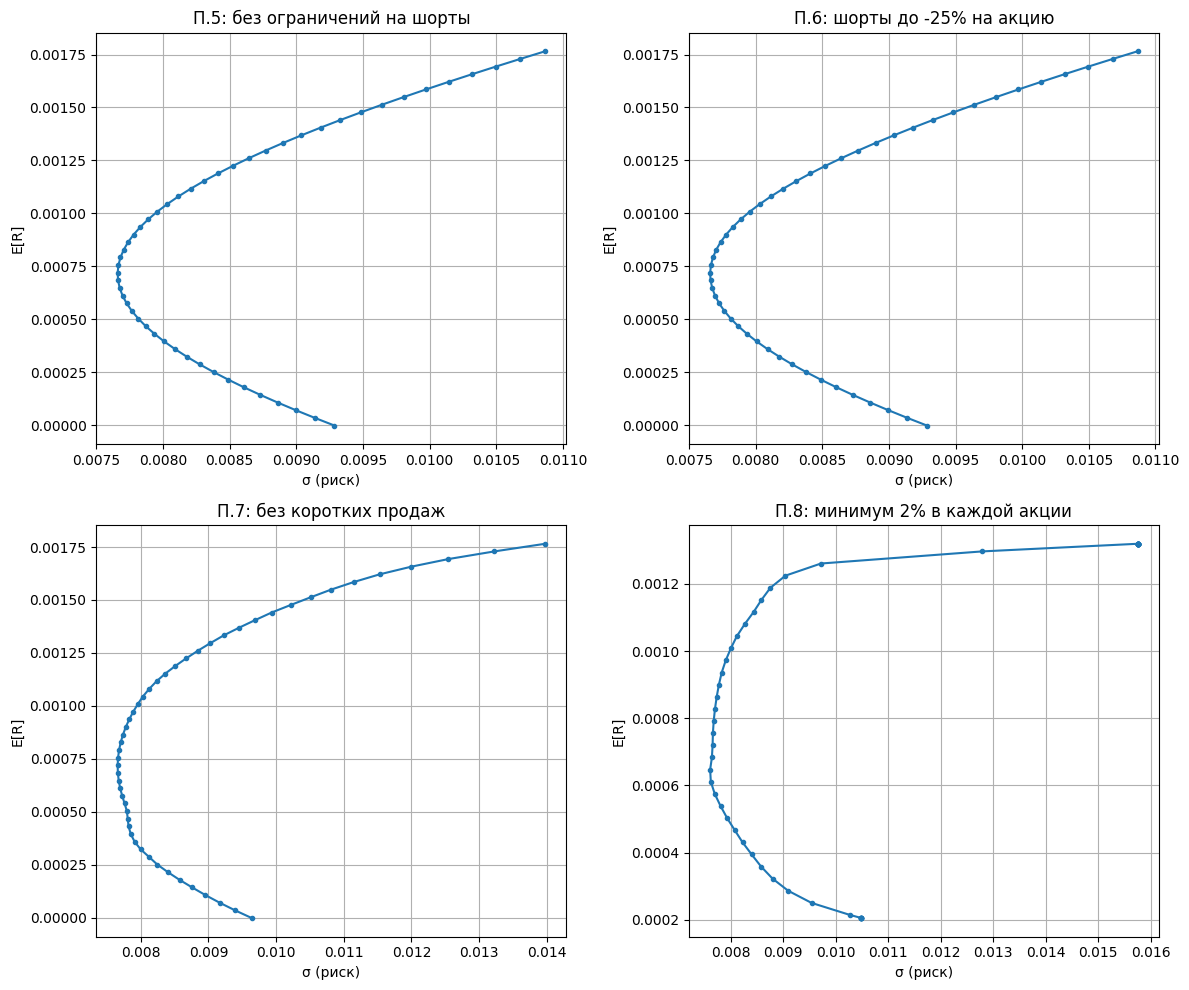

In [33]:
modes = [
    ("unconstrained", "П.5: без ограничений на шорты"),
    ("short_limited", "П.6: шорты до -25% на акцию"),
    ("no_short",      "П.7: без коротких продаж"),
    ("min_2pct",      "П.8: минимум 2% в каждой акции"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (mode, title) in zip(axes, modes):
    risks, rets = build_frontier(mu, Sigma, mode=mode, n_points=50)
    ax.plot(risks, rets, "o-", markersize=3)
    ax.set_title(title)
    ax.set_xlabel("σ (риск)")
    ax.set_ylabel("E[R]")
    ax.grid(True)

plt.tight_layout()
plt.show()

Для портфеля из \(n\) активов ожидаемая доходность портфеля равна

\[
E(R_p) = \sum_{j=1}^{n} w_j E(R_j)
\]

Дисперсия доходности портфеля равна

\[
\sigma_p^2 = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \operatorname{Cov}(R_i, R_j)
\]

Веса отдельных активов в портфеле должны суммироваться к 1:

\[
\sum_{j=1}^{n} w_j = 1
\]

надо бы два окна - до 2020 и с 2023 года? (ковид и политическая ситуация)

построить CML (capital market line)

Роль CML

Сначала строишь эффективную границу только из рискованных активов (Марковиц).

Потом проводишь из точки (0,R_f) касательную к этой границе: это и есть CML, она задаёт лучшую возможную линию риск–доходность для комбинаций «безрисковый актив + рыночный портфель».

Точки на CML и есть эффективные портфели в присутствии безрискового актива; точки под CML — неэффективные.



# 11. Выбрать индекс для расчёта исторических и скорректированных β. Привести обоснование выбора. 

что такое бета - коэффициент систематического риска (зависит от внешних обстоятельств), показывает как актив зависит от рынка и его динамики.

<img src="/Users/mariastarceva/Desktop/hse/risk management/project_1/Снимок экрана 2026-03-27 в 16.27.37.png" width="600">

выбираем индекс IMOEX, тк данные по ценам закрытия тикеров взяты с MOEX.

Какие индексы могли бы взять

1)RTS (долларовый индекс российских акций).
Логично, если ты работаешь в долларовой номинации и смотришь на риск/доходность с точки зрения иностранного инвестора.

2)MOEX Blue Chip Index.
Индекс 15 крупнейших и самых ликвидных компаний; хорошо подходит, если портфель состоит в основном из «голубых фишек».

3)MOEX Broad Market / SMID индексы.
Широкий рынок (топ‑100 акций) или индексы малой/средней капитализации; уместны, если у тебя много second‑tier бумаг, не ограничиваешься только фишками.

4)Секторальные индексы MOEX (например, нефтегаз, финансы).
Имеют смысл, если портфель почти моносекторальный и ты хочешь оценивать β к «своему» сектору, а не к широкому рынку.



# 12. Выбрать одно историческое окно и схему взвешивания наблюдений для последующего расчёта исторических и скорректированных β. Привести обоснование выбора. Оценка входящих данных для optimizer на основе исторических β 

схема взвешивания наблюдений - способ подсчета дисперсии и ковариации, от которых дальше по Марковицу будут находиться веса, надо минимизировать портфельную дисперсию для построения эффективной границы, поиск минимум-дисперсионного портфеля, максимизация доходности при заданном уровне риска.

<img src="/Users/mariastarceva/Desktop/hse/risk management/project_1/Снимок экрана 2026-03-27 в 17.13.06.png" width="400">

optimizer - 

<img src="/Users/mariastarceva/Desktop/hse/risk management/project_1/IMG_2783.jpg" width="400">

выбирается sma (с одинаковым весом), т.к. период не отличается высокой волатильностью

# 13. Рассчитать на выбранном в п. 12 историческом окне для отобранных акций ковариационную матрицу на основе исторических β (historical betas), которые оцениваются согласно рыночной модели (market model). 

In [61]:
df.dtypes

close    float64
SECID     object
dtype: object

In [43]:
!pip install apimoex requests pandas

In [45]:
import requests
import pandas as pd
import apimoex

start = "2015-01-01"
end   = "2019-12-31"

# История по инструменту IMOEX на рынке индексов
request_url = (
    "https://iss.moex.com/iss/history/engines/stock/markets/index/securities/IMOEX.json"
)

arguments = {
    "from": start,
    "till": end,
    "history.columns": "TRADEDATE,SECID,OPEN,HIGH,LOW,CLOSE,VALUE,VOLUME"
}

with requests.Session() as session:
    iss = apimoex.ISSClient(session, request_url, arguments)
    data = iss.get()

df_imoex = pd.DataFrame(data["history"])

# Оставляем дату и цену закрытия
df_imoex = df_imoex[["TRADEDATE", "CLOSE"]]
df_imoex["TRADEDATE"] = pd.to_datetime(df_imoex["TRADEDATE"])
df_imoex.set_index("TRADEDATE", inplace=True)
df_imoex = df_imoex.sort_index()

print(df_imoex.head())
print(df_imoex.tail())

              CLOSE
TRADEDATE          
2015-01-05  1435.66
2015-01-06  1480.73
2015-01-08  1547.39
2015-01-09  1515.37
2015-01-12  1513.22
              CLOSE
TRADEDATE          
2015-05-26  1651.66
2015-05-27  1660.98
2015-05-28  1657.62
2015-05-29  1609.19
2015-06-01  1616.94


In [63]:
# historical beta, how calculate asset returm, market returm and market variance?
# asset return = p(today) - p(yesterday) / p(yesterday)
# market return = index(today) - index(yesterday) / index(yesterday)
# market variance = variance(market return)

# historical beta
start_date = "2015-01-01"
end_date   = "2019-12-31"
# 1. Приводим дату к datetime и делаем её индексом
#df['date'] = pd.to_datetime(df['date'])
#df = df.set_index('date').sort_index()

returns = np.log(df['close'] / df['close'].shift(1)).dropna()

asset_returns = returns.loc[start_date:end_date]

market_returns = np.log(df_imoex['CLOSE'] / df_imoex['CLOSE'].shift(1)).dropna()

market_variance = market_returns.var()
# price_cols = df['SECID'].isin(['NLMK', 'IMOEX'])  # явно перечисли
# df_num = df[price_cols].apply(pd.to_numeric, errors='coerce')

# проверь, что всё стало float
# print(df_num.dtypes)

# теперь считаем доходности
# rets = np.log(df_num / df_num.shift(1)).dropna()

# rs = rets['NLMK']
# rm = rets['IMOEX']
# adjusted beta
print(asset_returns)

date
2015-01-05    0.598138
2015-01-05    1.154943
2015-01-05   -8.310777
2015-01-05    6.242850
2015-01-05    0.912654
                ...   
2019-12-30   -6.672230
2019-12-30    3.344170
2019-12-30   -1.987509
2019-12-30    4.586083
2019-12-30   -0.573581
Name: close, Length: 35855, dtype: float64


In [65]:
df_all = pd.read_csv("moex_close_2015_2025_no_apimoex.csv")
import statsmodels.api as sm

# 0. Приводим к виду: индекс = date, колонки = тикеры, значения = close
df_all['date'] = pd.to_datetime(df_all['date'])
prices = (
    df_all
    .pivot(index='date', columns='SECID', values='close')
    .sort_index()
)

# 1. Цены индекса IMOEX уже в df_imoex с индексом-датой и колонкой CLOSE
df_imoex.index = pd.to_datetime(df_imoex.index)
df_imoex = df_imoex.sort_index()

# 2. Доходности акций и индекса
asset_rets = np.log(prices / prices.shift(1))      # DataFrame: даты × тикеры
market_rets = np.log(df_imoex['CLOSE'] / df_imoex['CLOSE'].shift(1))

# 3. Срез по окну
start_date = "2015-01-01"
end_date   = "2019-12-31"

asset_rets = asset_rets.loc[start_date:end_date]
market_rets = market_rets.loc[start_date:end_date]

# 4. Выровнять по общим датам
common_idx = asset_rets.index.intersection(market_rets.index)
asset_rets = asset_rets.loc[common_idx]
market_rets = market_rets.loc[common_idx]

# 5. Оценка beta и дисперсий остатков для КАЖДОГО тикера
betas = {}
resid_vars = {}

rm = market_rets.values  # numpy-массив рынка
X = sm.add_constant(rm)

for ticker in asset_rets.columns:
    rs = asset_rets[ticker].dropna()
    # выравниваем на случай пропусков по конкретному тикеру
    idx = rs.index.intersection(market_rets.index)
    y = rs.loc[idx].values
    X_t = sm.add_constant(market_rets.loc[idx].values)

    model = sm.OLS(y, X_t).fit()
    betas[ticker] = model.params[1]                # beta_i
    resid_vars[ticker] = model.resid.var(ddof=1)   # σ^2_{ε,i}

betas = pd.Series(betas)
resid_vars = pd.Series(resid_vars)

# 6. Дисперсия рынка
sigma_m2 = market_rets.var(ddof=1)

# 7. Ковариационная матрица Σ(β) по market model
tickers = betas.index.tolist()
n = len(tickers)

cov_beta = pd.DataFrame(np.zeros((n, n)), index=tickers, columns=tickers)

for i in range(n):
    for j in range(n):
        ti, tj = tickers[i], tickers[j]
        if i == j:
            cov_beta.iloc[i, j] = betas[ti]**2 * sigma_m2 + resid_vars[ti]
        else:
            cov_beta.iloc[i, j] = betas[ti] * betas[tj] * sigma_m2

print(cov_beta)

          AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
AFLT  0.000602  0.000108  0.000159  0.000083  0.000056  0.000087  0.000175   
ALRS  0.000108  0.000853  0.000137  0.000072  0.000049  0.000075  0.000152   
APTK  0.000159  0.000137  0.003106  0.000106  0.000072  0.000111  0.000223   
BANE  0.000083  0.000072  0.000106  0.000710  0.000038  0.000058  0.000117   
BRZL  0.000056  0.000049  0.000072  0.000038  0.003307  0.000039  0.000079   
CHMF  0.000087  0.000075  0.000111  0.000058  0.000039  0.000458  0.000122   
FEES  0.000175  0.000152  0.000223  0.000117  0.000079  0.000122  0.001317   
GCHE  0.000031  0.000027  0.000040  0.000021  0.000014  0.000022  0.000044   
IRKT  0.000081  0.000070  0.000103  0.000054  0.000037  0.000056  0.000114   
KUZB -0.000549 -0.000476 -0.000702 -0.000368 -0.000249 -0.000384 -0.000774   
MGNT  0.000171  0.000148  0.000218  0.000114  0.000077  0.000119  0.000240   
MOEX  0.000144  0.000124  0.000183  0.000096  0.000065  0.000100

In [68]:
print(betas)

AFLT    0.733734
ALRS    0.636101
APTK    0.936970
BANE    0.490948
BRZL    0.333043
CHMF    0.512570
FEES    1.034287
GCHE    0.184948
IRKT    0.476452
KUZB   -3.246882
MGNT    1.008370
MOEX    0.848172
MTLR    1.068116
MTSS    0.887674
MVID    0.886054
NLMK    0.674550
NMTP    0.371873
NVTK    1.017327
PHOR    0.326874
PIKK    0.151990
PLZL    0.149208
RASP    0.964847
SBER    1.218006
SNGS    1.255702
TATN    1.471459
TRMK    0.666331
UKUZ    0.478368
UTAR    0.606293
VTBR    0.645347
dtype: float64


In [52]:
print(type(returns.index))
print(returns.index[:5])
print(asset_returns.head())
print(asset_returns.tail())

<class 'pandas.core.indexes.base.Index'>
Index([1, 2, 3, 4, 5], dtype='int64')
2016    0.001627
2017    0.001625
2018    0.016103
2019    0.022118
Name: close, dtype: float64
2016    0.001627
2017    0.001625
2018    0.016103
2019    0.022118
Name: close, dtype: float64


# 14. Построить границу эффективных портфелей на основе полученной в п. 13 ковариационной матрицы. 

In [66]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# mu: ожидаемые доходности по тикерам (можно взять средние исторические)
# например, из тех же returns, что ты считала для бет:
# returns_df: DataFrame дат × тикеры с лог-доходностями
mu = asset_rets.mean()  # pd.Series, index = те же тикеры, что в cov_beta

Sigma = cov_beta.values
tickers = cov_beta.index.tolist()
n = len(tickers)

def portfolio_stats(w, mu, Sigma):
    ret = np.dot(w, mu)
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol

def min_vol_for_target_ret(target_ret, mu, Sigma):
    # целевая функция: минимизировать дисперсию (или vol^2)
    def obj(w):
        return w @ Sigma @ w

    # ограничения: сумма весов = 1, доходность = target_ret
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w: np.dot(w, mu) - target_ret},
    )
    # веса >= 0
    bounds = tuple((0.0, 1.0) for _ in range(n))
    w0 = np.repeat(1.0/n, n)

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    return res.x

# диапазон целевых доходностей (между мин и макс средних)
target_rets = np.linspace(mu.min(), mu.max(), 50)

frontier_vols = []
frontier_rets = []

for r_target in target_rets:
    w_opt = min_vol_for_target_ret(r_target, mu.values, Sigma)
    ret, vol = portfolio_stats(w_opt, mu.values, Sigma)
    frontier_rets.append(ret)
    frontier_vols.append(vol)

frontier_rets = np.array(frontier_rets)
frontier_vols = np.array(frontier_vols)

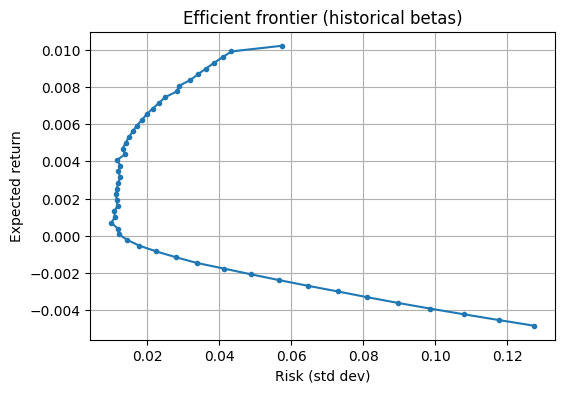

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(frontier_vols, frontier_rets, '-o', ms=3)
plt.xlabel('Risk (std dev)')
plt.ylabel('Expected return')
plt.title('Efficient frontier (historical betas)')
plt.grid(True)
plt.show()

# 15. (*) Построить границу эффективных портфелей для разных исторических окон (см. п. 2 для определения исторических окон) и продемонстрировать динамику её изменения. Другими словами, выполнить пп. 13-14 не для одного (см. п. 12), а для разных окон (см. п. 2). Оценка входящих данных для optimizer на основе скорректированных β 
# 18. (*) Построить границу эффективных портфелей для разных исторических окон (см. п. 2 для определения исторических окно) и продемонстрировать динамику её изменения. Другими словами, выполнить пп. 16-17 не для одного (см. п. 12), а для разных окон (см. п. 2). 


Year 2015
Asset window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
Market window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
N dates: 100 N tickers: 29

Year 2016
Asset window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
Market window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
N dates: 100 N tickers: 29

Year 2017
Asset window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
Market window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
N dates: 100 N tickers: 29

Year 2018
Asset window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
Market window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
N dates: 100 N tickers: 29

Year 2019
Asset window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
Market window: 2015-01-05 00:00:00 -> 2015-06-01 00:00:00
N dates: 100 N tickers: 29



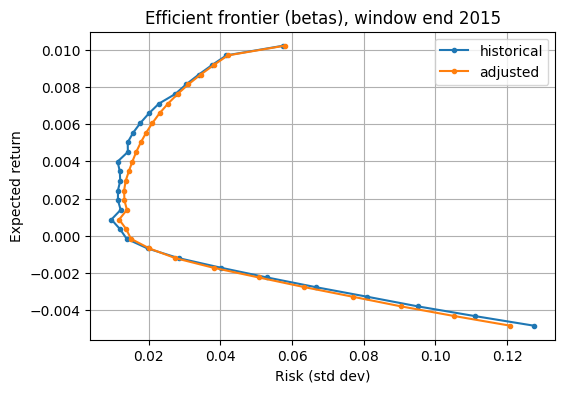

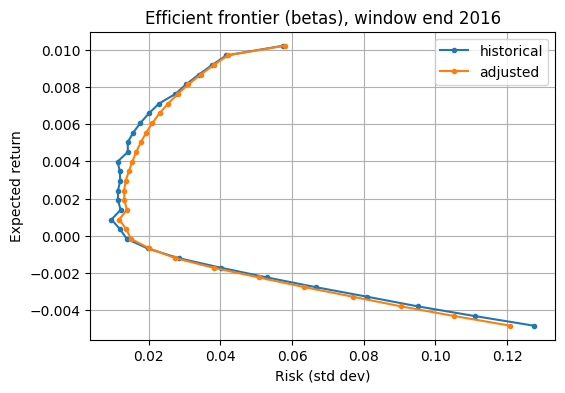

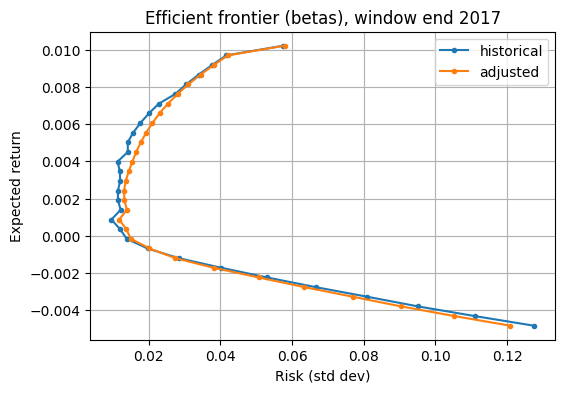

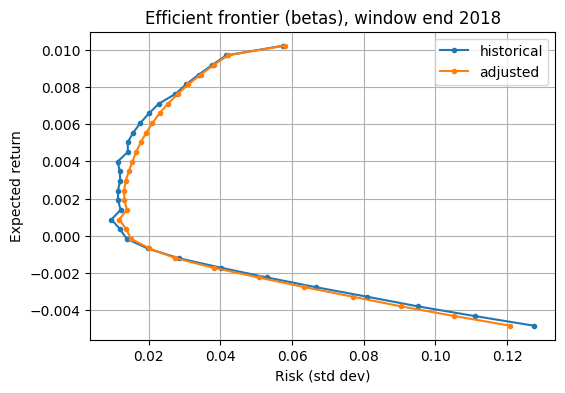

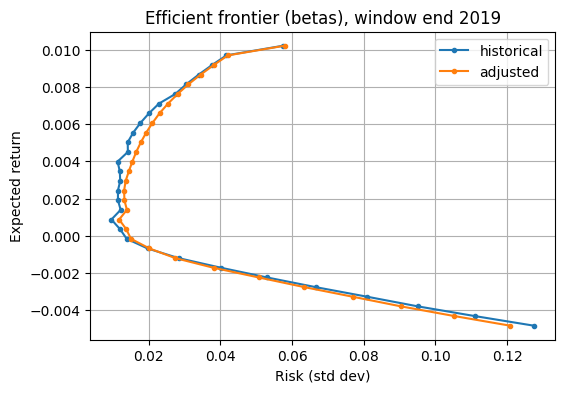

In [77]:
df = pd.read_csv("moex_close_2015_2025_no_apimoex.csv")
# акции: date, SECID, close
df['date'] = pd.to_datetime(df['date'])
prices = (
    df
    .pivot(index='date', columns='SECID', values='close')
    .sort_index()
)

# индекс IMOEX: индекс уже дата, колонка CLOSE
df_imoex.index = pd.to_datetime(df_imoex.index)
df_imoex = df_imoex.sort_index()

# лог-доходности акций и рынка
asset_rets_full = np.log(prices / prices.shift(1))
market_rets_full = np.log(df_imoex['CLOSE'] / df_imoex['CLOSE'].shift(1))

# рабочий диапазон
start_date_global = "2015-01-01"
end_date_global   = "2019-12-31"

asset_rets_full = asset_rets_full.loc[start_date_global:end_date_global]
market_rets_full = market_rets_full.loc[start_date_global:end_date_global]

# список годов для expanding window (концы окон)
years = [2015, 2016, 2017, 2018, 2019]

# === 1. Функции для оптимизации (одни и те же для всех окон) ===

def portfolio_stats(w, mu, Sigma):
    ret = np.dot(w, mu)
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol

def min_vol_for_target_ret(target_ret, mu, Sigma):
    n = len(mu)

    def obj(w):
        return w @ Sigma @ w

    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w: np.dot(w, mu) - target_ret},
    )
    bounds = tuple((0.0, 1.0) for _ in range(n))
    w0 = np.repeat(1.0 / n, n)

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    return res.x

# будем хранить результат границ в одном списке
frontier_records = []

# === 2. Цикл по расширяющимся окнам ===

for year_end in years:
    window_end = f"{year_end}-12-31"
    window_start = start_date_global  # расширяющееся окно от 2015-01-01

    # 2.1. Срез доходностей в окне
    asset_rets = asset_rets_full.loc[window_start:window_end]
    market_rets = market_rets_full.loc[window_start:window_end]

    # выравниваем даты
    common_idx = asset_rets.index.intersection(market_rets.index)
    asset_rets = asset_rets.loc[common_idx]
    market_rets = market_rets.loc[common_idx]

    # выбрасываем тикеры, у которых всё NaN в этом окне
    asset_rets = asset_rets.dropna(axis=1, how='all')
    tickers = asset_rets.columns.tolist()
    n = len(tickers)
    if n < 2:
        continue  # слишком мало бумаг, чтобы строить границу
    print("Year", year_end)
    print("Asset window:", asset_rets.index.min(), "->", asset_rets.index.max())
    print("Market window:", market_rets.index.min(), "->", market_rets.index.max())
    print("N dates:", len(asset_rets), "N tickers:", asset_rets.shape[1])
    print()
    # 2.2. Оценка historical beta и дисперсий остатков
    betas_hist = {}
    resid_vars = {}

    for ticker in tickers:
        rs = asset_rets[ticker].dropna()
        idx = rs.index.intersection(market_rets.index)
        if len(idx) < 10:
            continue  # мало наблюдений для регрессии

        y = rs.loc[idx].values
        X = sm.add_constant(market_rets.loc[idx].values)

        model = sm.OLS(y, X).fit()
        beta_i = model.params[1]
        betas_hist[ticker] = beta_i
        resid_vars[ticker] = model.resid.var(ddof=1)

    # синхронизируем по тем тикерам, у которых beta посчиталась
    tickers_beta = list(betas_hist.keys())
    if len(tickers_beta) < 2:
        continue

    betas_hist = pd.Series(betas_hist)
    resid_vars = pd.Series(resid_vars)[betas_hist.index]

    # 2.3. Adjusted betas (Blume)
    betas_adj = 0.33 + 0.67 * betas_hist
    betas_adj = betas_adj.astype(float)

    # 2.4. Дисперсия рынка
    sigma_m2 = market_rets.var(ddof=1)

    # 2.5. Ковариационная матрица Σ(historical β)
    tickers_final = betas_hist.index.tolist()
    n_final = len(tickers_final)

    cov_beta = pd.DataFrame(
        np.zeros((n_final, n_final)),
        index=tickers_final,
        columns=tickers_final,
    )
    cov_beta_adj = cov_beta.copy()

    for i in range(n_final):
        for j in range(n_final):
            ti, tj = tickers_final[i], tickers_final[j]
            if i == j:
                cov_beta.iloc[i, j] = betas_hist[ti]**2 * sigma_m2 + resid_vars[ti]
                cov_beta_adj.iloc[i, j] = betas_adj[ti]**2 * sigma_m2 + resid_vars[ti]
            else:
                cov_beta.iloc[i, j] = betas_hist[ti] * betas_hist[tj] * sigma_m2
                cov_beta_adj.iloc[i, j] = betas_adj[ti] * betas_adj[tj] * sigma_m2

    # 2.6. Вектор средних доходностей μ (по тем же тикерам и окну)
    mu_window = asset_rets[tickers_final].mean()

    # диапазон целевых доходностей (между мин и макс μ)
    target_rets = np.linspace(mu_window.min(), mu_window.max(), 30)

    # 2.7. Граница для historical β
    for r_target in target_rets:
        w_opt = min_vol_for_target_ret(r_target, mu_window.values, cov_beta.values)
        ret, vol = portfolio_stats(w_opt, mu_window.values, cov_beta.values)
        frontier_records.append({
            "window_end_year": year_end,
            "beta_type": "historical",
            "ret": ret,
            "vol": vol,
        })

    # 2.8. Граница для adjusted β
    for r_target in target_rets:
        w_opt = min_vol_for_target_ret(r_target, mu_window.values, cov_beta_adj.values)
        ret, vol = portfolio_stats(w_opt, mu_window.values, cov_beta_adj.values)
        frontier_records.append({
            "window_end_year": year_end,
            "beta_type": "adjusted",
            "ret": ret,
            "vol": vol,
        })

# === 3. Собираем всё в DataFrame и рисуем ===

frontier_df = pd.DataFrame(frontier_records)

# frontier_df: columns = ['window_end_year', 'beta_type', 'ret', 'vol']

for year_end in years:
    df_y = frontier_df[frontier_df['window_end_year'] == year_end]
    if df_y.empty:
        continue

    plt.figure(figsize=(6, 4))

    for beta_type, color in [("historical", "tab:blue"),
                             ("adjusted", "tab:orange")]:
        mask = df_y['beta_type'] == beta_type
        if not mask.any():
            continue
        plt.plot(
            df_y.loc[mask, 'vol'],
            df_y.loc[mask, 'ret'],
            '-o',
            ms=3,
            label=beta_type
        )

    plt.xlabel("Risk (std dev)")
    plt.ylabel("Expected return")
    plt.title(f"Efficient frontier (betas), window end {year_end}")
    plt.grid(True)
    plt.legend()
    plt.show()

# 16. Рассчитать на выбранном в п. 12 историческом окне для отобранных акций ковариационную матрицу на основе скорректированных β (adjusted betas). 
# 17. Построить границу эффективных портфелей на основе полученной в п. 16 ковариационной матрицы. 


In [ ]:
betas_adj = {}

for ticker in asset_rets.columns:
    rs = asset_rets[ticker].dropna()
    # выравниваем на случай пропусков по конкретному тикеру
    idx = rs.index.intersection(market_rets.index)
    y = rs.loc[idx].values
    X_t = sm.add_constant(market_rets.loc[idx].values)

    model = sm.OLS(y, X_t).fit()
    betas_adj[ticker] = 0.33+0.67*model.params[1]                # beta_i

betas_adj = pd.Series(betas_adj)

# 6. Дисперсия рынка
sigma_m2 = market_rets.var(ddof=1)

# 7. Ковариационная матрица Σ(β) по market model
tickers = betas_adj.index.tolist()
n = len(tickers)

cov_beta_adj = pd.DataFrame(np.zeros((n, n)), index=tickers, columns=tickers)

for i in range(n):
    for j in range(n):
        ti, tj = tickers[i], tickers[j]
        if i == j:
            cov_beta_adj.iloc[i, j] = betas_adj[ti]**2 * sigma_m2 + resid_vars[ti]
        else:
            cov_beta_adj.iloc[i, j] = betas_adj[ti] * betas_adj[tj] * sigma_m2

print(cov_beta_adj)

          AFLT      ALRS      APTK      BANE      BRZL      CHMF      FEES  \
AFLT  0.000634  0.000143  0.000181  0.000125  0.000105  0.000128  0.000194   
ALRS  0.000143  0.000891  0.000167  0.000115  0.000096  0.000117  0.000178   
APTK  0.000181  0.000167  0.003115  0.000146  0.000122  0.000149  0.000226   
BANE  0.000125  0.000115  0.000146  0.000755  0.000084  0.000102  0.000155   
BRZL  0.000105  0.000096  0.000122  0.000084  0.003352  0.000086  0.000130   
CHMF  0.000128  0.000117  0.000149  0.000102  0.000086  0.000502  0.000159   
FEES  0.000194  0.000178  0.000226  0.000155  0.000130  0.000159  0.001311   
GCHE  0.000086  0.000079  0.000100  0.000069  0.000058  0.000070  0.000107   
IRKT  0.000123  0.000113  0.000143  0.000099  0.000083  0.000101  0.000153   
KUZB -0.000350 -0.000322 -0.000408 -0.000280 -0.000235 -0.000287 -0.000435   
MGNT  0.000191  0.000175  0.000222  0.000153  0.000128  0.000156  0.000237   
MOEX  0.000170  0.000157  0.000198  0.000136  0.000115  0.000139

In [72]:
# mu: ожидаемые доходности по тикерам (можно взять средние исторические)
# например, из тех же returns, что ты считала для бет:
# returns_df: DataFrame дат × тикеры с лог-доходностями
mu = asset_rets.mean()  # pd.Series, index = те же тикеры, что в cov_beta

Sigma = cov_beta_adj.values
tickers = cov_beta_adj.index.tolist()
n = len(tickers)
# диапазон целевых доходностей (между мин и макс средних)
target_rets = np.linspace(mu.min(), mu.max(), 50)

frontier_vols = []
frontier_rets = []

for r_target in target_rets:
    w_opt = min_vol_for_target_ret(r_target, mu.values, Sigma)
    ret, vol = portfolio_stats(w_opt, mu.values, Sigma)
    frontier_rets.append(ret)
    frontier_vols.append(vol)

frontier_rets = np.array(frontier_rets)
frontier_vols = np.array(frontier_vols)

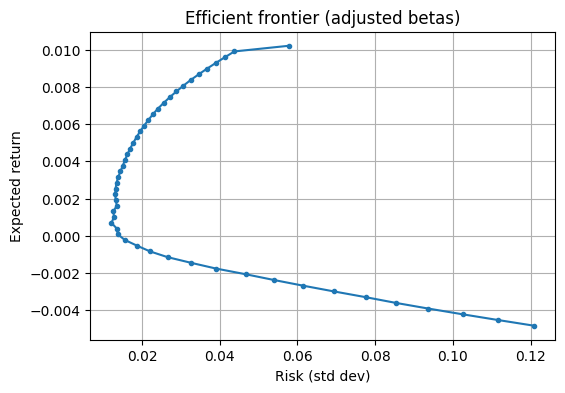

In [73]:
plt.figure(figsize=(6,4))
plt.plot(frontier_vols, frontier_rets, '-o', ms=3)
plt.xlabel('Risk (std dev)')
plt.ylabel('Expected return')
plt.title('Efficient frontier (adjusted betas)')
plt.grid(True)
plt.show()

# 19. Сравнить на выбранном в п. 12 историческом окне для отобранных акций границы эффективных портфелей, рассчитанные тремя различными способами: на основе исторических доходностей, исторических и скорректированных β. Привести экономическую интерпретацию полученных результатов. 
# 20. (*) Выполнить п. 19 для разных окон (см. п. 2). Привести экономическую интерпретацию полученных результатов. 
